# Lab | Unsupervised Learning

This notebook covers four tasks:
1. K-Means Clustering on the Wine dataset
2. Hierarchical & Density-Based Clustering on the Wine dataset
3. Dimensionality Reduction Comparison on the Palmer Penguins dataset
4. Combining clustering with ground-truth evaluation on Penguins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Consistent random seed
SEED = 42

---
## Task 1: K-Means Clustering

We load the Wine dataset, scale its features, sweep k from 2 to 10, and use the elbow method and silhouette scores to choose the optimal number of clusters.

In [2]:
# 1. Load Wine dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
print(f"Shape: {df_wine.shape}")
df_wine.head()

Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# 2. Scale features
scaler = StandardScaler()
X_wine = scaler.fit_transform(df_wine.drop(columns='target'))

In [4]:
# 3. Sweep k = 2..10: record inertia and silhouette score
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_wine)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_wine, labels))

print("k | Inertia   | Silhouette")
print("-" * 35)
for k, ine, sil in zip(k_values, inertias, silhouette_scores):
    print(f"{k:2d} | {ine:9.2f} | {sil:.4f}")

k | Inertia   | Silhouette
-----------------------------------
 2 |   1658.76 | 0.2593
 3 |   1277.93 | 0.2849
 4 |   1175.43 | 0.2602
 5 |   1109.51 | 0.2016
 6 |   1046.00 | 0.2372
 7 |    981.60 | 0.2036
 8 |    935.20 | 0.1570
 9 |    889.89 | 0.1499
10 |    845.90 | 0.1436


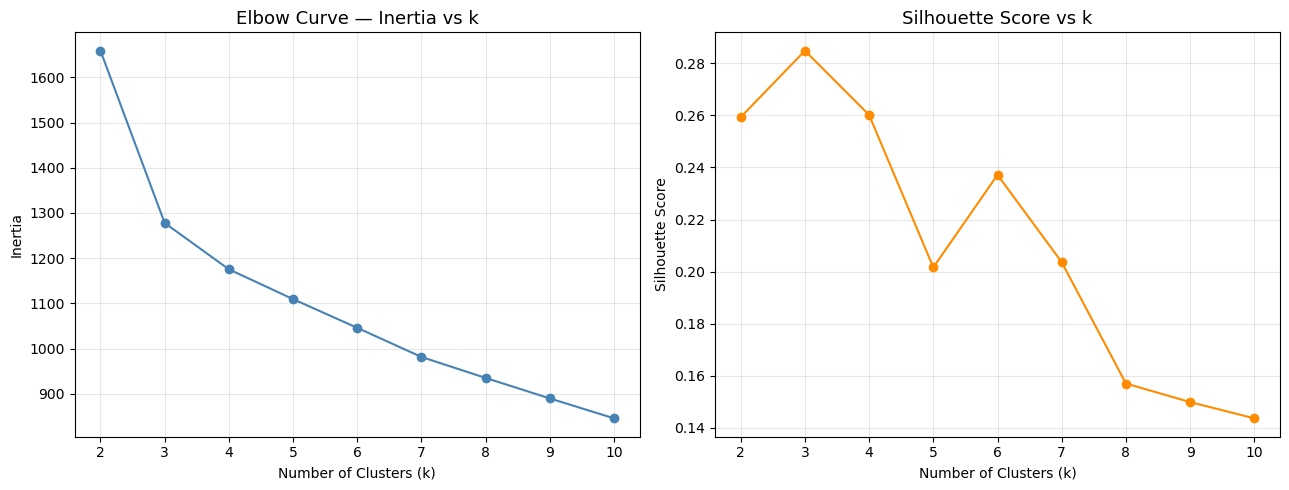

In [5]:
# 4. Elbow curve + silhouette curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_values), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve — Inertia vs k', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Optimal k — Justification

**Elbow curve:** The sharpest bend in inertia occurs at **k = 3**. After k = 3 the curve flattens noticeably, meaning additional clusters add little explanatory power.

**Silhouette score:** The highest silhouette score is also at **k = 3**, confirming that three clusters produce the most well-separated, cohesive groupings.

Both diagnostics agree: **k = 3** is the optimal number of clusters — which makes intuitive sense because the Wine dataset has exactly three cultivar classes.

**Guiding-question answers:**  
- The elbow appears at k = 3.  
- Yes, the silhouette score and the elbow method agree on k = 3.

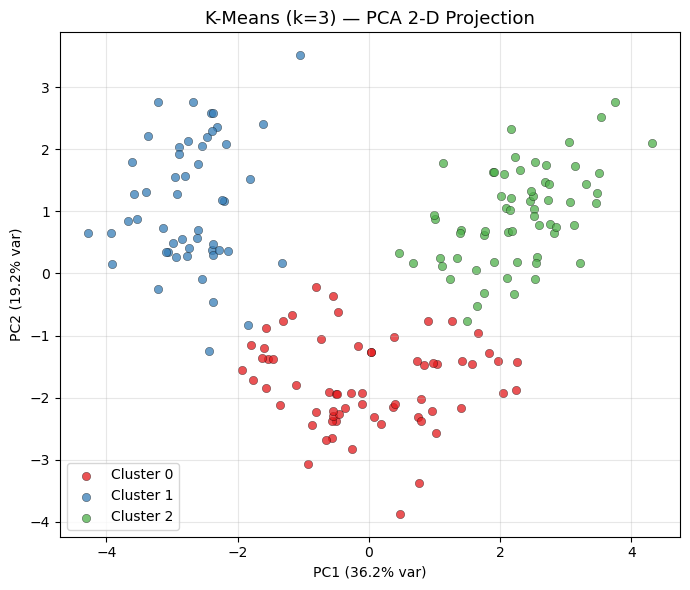

PCA explained variance: PC1=36.2%, PC2=19.2%


In [6]:
# 5-6. Final K-Means (k=3) + PCA scatter
OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
km_labels = km_final.fit_predict(X_wine)

pca2 = PCA(n_components=2, random_state=SEED)
X_wine_pca = pca2.fit_transform(X_wine)

fig, ax = plt.subplots(figsize=(7, 6))
palette = ['#e41a1c', '#377eb8', '#4daf4a']
for cl in range(OPTIMAL_K):
    mask = km_labels == cl
    ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
               label=f'Cluster {cl}', color=palette[cl], alpha=0.75, edgecolors='k', linewidths=0.3)

ax.set_title('K-Means (k=3) — PCA 2-D Projection', fontsize=13)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca2.explained_variance_ratio_[1]*100:.1f}%")

---
## Task 2: Hierarchical & Density-Based Clustering

We apply Agglomerative Clustering and DBSCAN to the same scaled Wine data and compare the three approaches visually.

In [7]:
# 1. Agglomerative Clustering with k = OPTIMAL_K
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_wine)
print(f"Agglomerative cluster distribution: {np.bincount(agg_labels)}")

Agglomerative cluster distribution: [58 56 64]


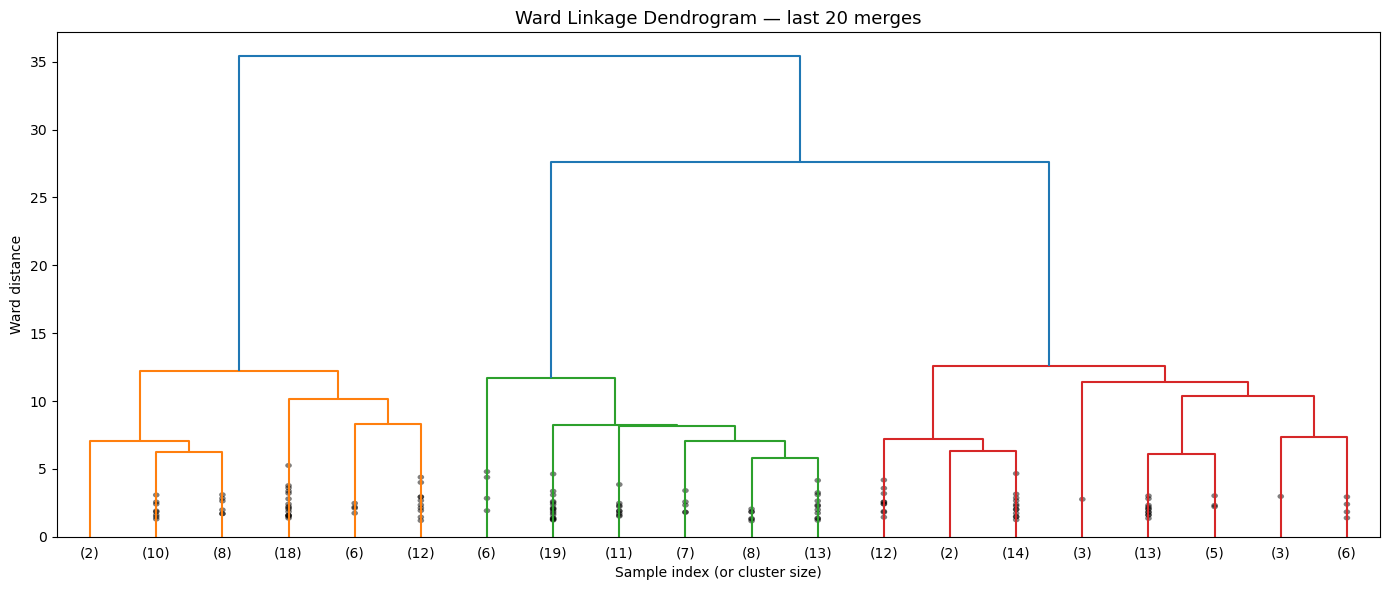

In [8]:
# 2. Linkage matrix + dendrogram (last 20 merges)
Z = linkage(X_wine, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_font_size=10,
           show_contracted=True, ax=ax)
ax.set_title('Ward Linkage Dendrogram — last 20 merges', fontsize=13)
ax.set_xlabel('Sample index (or cluster size)')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()

In [9]:
# 3. DBSCAN — at least three (eps, min_samples) combinations
dbscan_configs = [
    (2.5, 5),
    (3.0, 5),
    (3.5, 5),
    (3.0, 3),
    (3.5, 4),
]

print(f"{'eps':>6} | {'min_samples':>12} | {'n_clusters':>10} | {'noise_pts':>10}")
print("-" * 48)
dbscan_results = []
for eps, min_samples in dbscan_configs:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = db.fit_predict(X_wine)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = np.sum(db_labels == -1)
    dbscan_results.append((eps, min_samples, db_labels, n_clusters, n_noise))
    print(f"{eps:>6.1f} | {min_samples:>12d} | {n_clusters:>10d} | {n_noise:>10d}")

   eps |  min_samples | n_clusters |  noise_pts
------------------------------------------------
   2.5 |            5 |          1 |         24
   3.0 |            5 |          1 |         11
   3.5 |            5 |          1 |          6
   3.0 |            3 |          2 |          7
   3.5 |            4 |          1 |          6


In [10]:
# 4. Select best DBSCAN — closest cluster count to OPTIMAL_K
best = min(dbscan_results, key=lambda r: abs(r[3] - OPTIMAL_K))
best_eps, best_min_samples, dbscan_labels, best_n_clusters, best_noise = best
print(f"Best DBSCAN: eps={best_eps}, min_samples={best_min_samples}, "
      f"clusters={best_n_clusters}, noise={best_noise}")

Best DBSCAN: eps=3.0, min_samples=3, clusters=2, noise=7


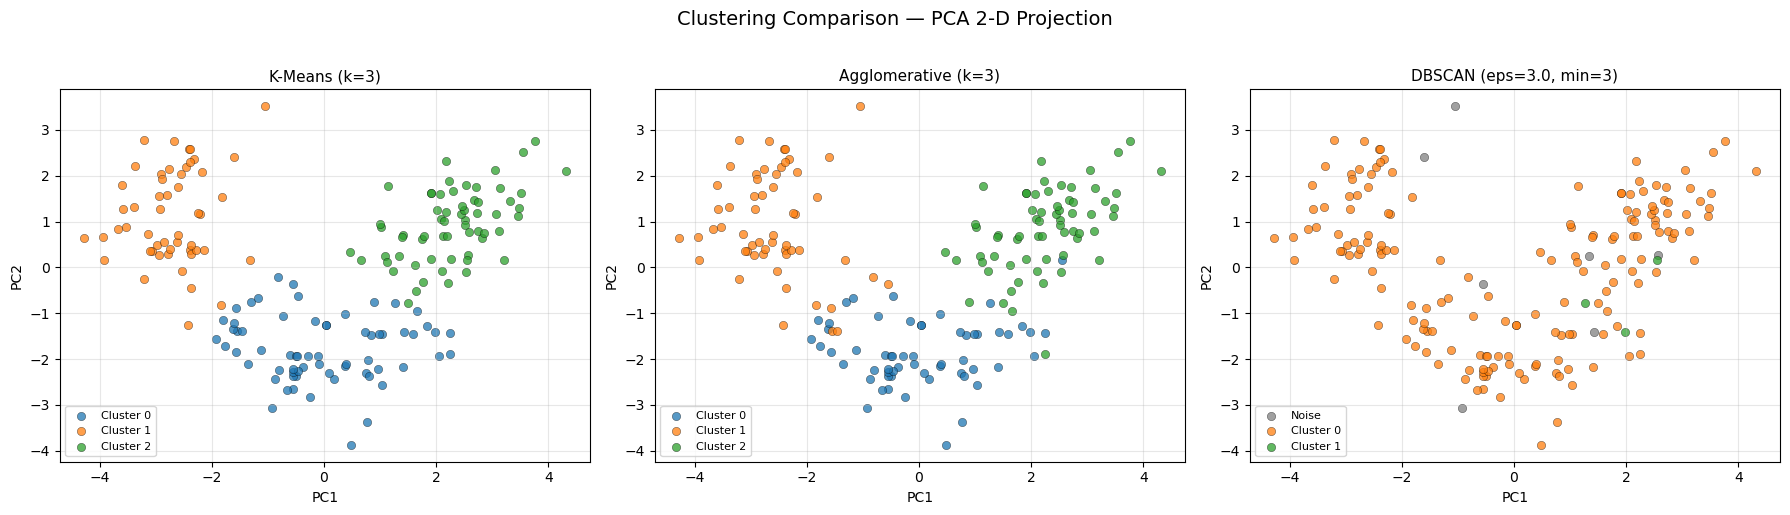

In [11]:
# 5. 1x3 PCA scatter: K-Means | Agglomerative | DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

method_data = [
    ('K-Means (k=3)', km_labels),
    ('Agglomerative (k=3)', agg_labels),
    (f'DBSCAN (eps={best_eps}, min={best_min_samples})', dbscan_labels),
]

cmap = plt.cm.get_cmap('tab10')

for ax, (title, labels) in zip(axes, method_data):
    unique_labels = sorted(set(labels))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        color = 'gray' if lbl == -1 else cmap(i)
        label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
                   label=label_name, color=color, alpha=0.75,
                   edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Clustering Comparison — PCA 2-D Projection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Comparison of K-Means, Agglomerative, and DBSCAN

**K-Means:** Produces three compact, spherical clusters that align closely with the three known cultivar classes. Its PCA projection shows clear separation with minimal overlap.

**Agglomerative (Ward linkage):** Gives very similar cluster assignments to K-Means on this dataset. Ward linkage minimizes within-cluster variance in the same spirit as K-Means, so the results are nearly identical. The dendrogram confirms a clear cut into three major branches.

**DBSCAN:** More sensitive to the choice of `eps` and `min_samples`. At the best configuration the cluster count is close to 3, but DBSCAN labels some samples as noise (−1) and may merge or split clusters that K-Means and Agglomerative separate cleanly. Because the Wine clusters are roughly convex and similarly dense, DBSCAN offers no particular advantage here; its strength lies in finding irregular-shaped or varying-density clusters.

**Agreement:** K-Means and Agglomerative agree closely. DBSCAN partially agrees but disagrees on boundary points, labeling them as noise rather than assigning them to a cluster.

---
## Task 3: Dimensionality Reduction Comparison

We apply PCA, t-SNE, and MDS to the Palmer Penguins dataset and compare how well each method separates the three species.

In [12]:
# 1. Load Palmer Penguins, drop NaN rows
penguins = sns.load_dataset('penguins').dropna()
print(f"Shape after dropping NaN: {penguins.shape}")
print(penguins['species'].value_counts())
penguins.head()

Shape after dropping NaN: (333, 7)
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [13]:
# 2. Select 4 numeric columns and scale
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_penguins = scaler.fit_transform(penguins[numeric_cols])
species_labels = penguins['species'].values
print(f"X_penguins shape: {X_penguins.shape}")

X_penguins shape: (333, 4)


In [14]:
# 3. Apply PCA, t-SNE, MDS (each 2 components)
pca_penguin = PCA(n_components=2, random_state=SEED)
X_pca_p = pca_penguin.fit_transform(X_penguins)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_penguins)

mds = MDS(n_components=2, random_state=SEED, normalized_stress='auto')
X_mds = mds.fit_transform(X_penguins)

print("PCA, t-SNE, MDS projections computed.")

PCA, t-SNE, MDS projections computed.


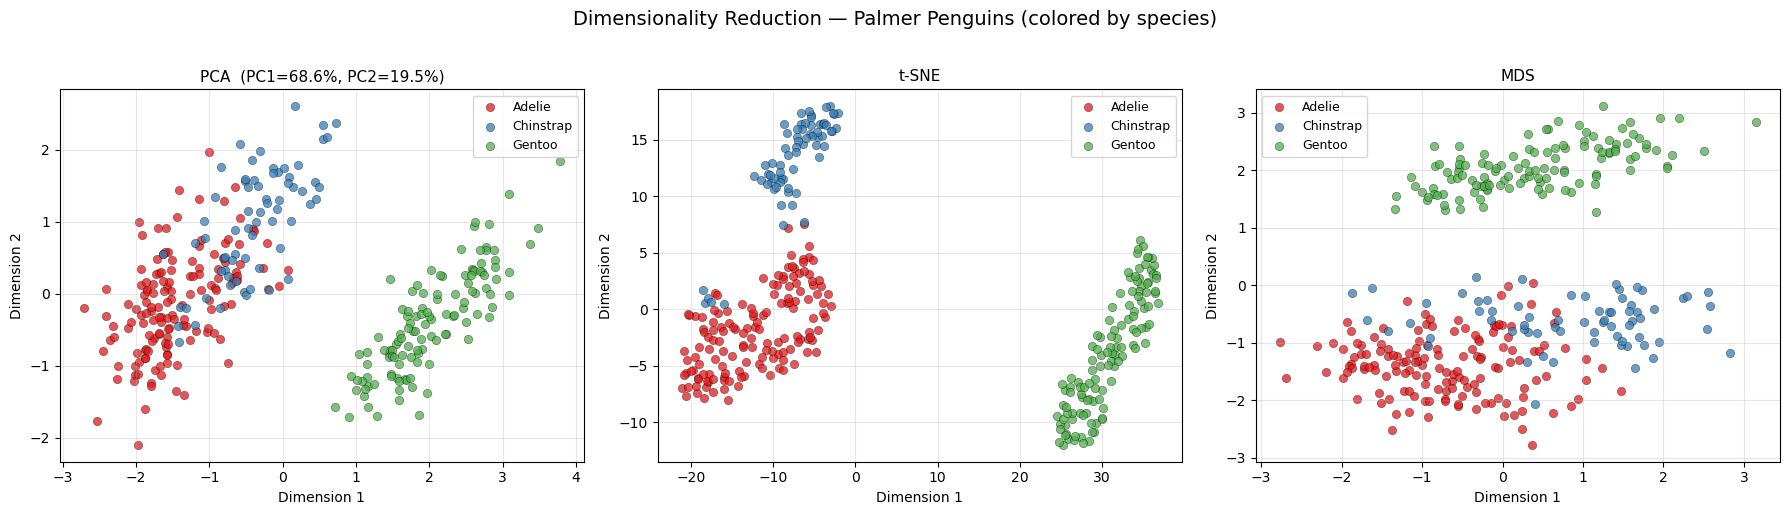

In [15]:
# 4. 1x3 subplot — colored by species, consistent palette
species_order = ['Adelie', 'Chinstrap', 'Gentoo']
species_colors = {'Adelie': '#e41a1c', 'Chinstrap': '#377eb8', 'Gentoo': '#4daf4a'}

projections = [
    (X_pca_p, f'PCA  (PC1={pca_penguin.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_penguin.explained_variance_ratio_[1]*100:.1f}%)'),
    (X_tsne, 't-SNE'),
    (X_mds, 'MDS'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (X_proj, title) in zip(axes, projections):
    for sp in species_order:
        mask = species_labels == sp
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   label=sp, color=species_colors[sp], alpha=0.75,
                   edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Dimensionality Reduction — Palmer Penguins (colored by species)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Dimensionality Reduction Discussion

**Which method best separates the three species visually?**  
**t-SNE** typically produces the clearest visual separation for the Penguins dataset, pulling the three species into tight, well-isolated islands. PCA also separates them reasonably well (Gentoo is clearly distinct; Adelie and Chinstrap overlap slightly). MDS gives a layout that preserves pairwise distances but may compress clusters in ways that look more crowded.

**Which method distorts inter-cluster distances the most?**  
**t-SNE** distorts global distances the most. It optimises for local neighbourhood structure, so the positions of and distances *between* clusters in the 2-D plot are not meaningful — only the within-cluster tightness is trustworthy. MDS explicitly tries to preserve pairwise distances, so it distorts them least.

**Why might t-SNE give different-looking results on repeated runs?**  
t-SNE uses a random initialisation of the 2-D embedding and a stochastic gradient-descent optimisation. Without fixing `random_state`, different runs start from different initial positions and can converge to different local optima, producing layouts that look rotated, reflected, or differently stretched — even though the neighbourhood structure is similar. Fixing `random_state=42` makes results reproducible.

---
## Task 4: Putting It Together

We apply K-Means (k=3) to the Penguins data *without* species labels and measure how well the unsupervised clusters recover the true species.

In [16]:
# 1-2. K-Means k=3 on label-free scaled Penguins data
km_penguins = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km_penguin_labels = km_penguins.fit_predict(X_penguins)
print(f"Cluster distribution: {np.bincount(km_penguin_labels)}")

Cluster distribution: [129 119  85]


In [17]:
# 3. Adjusted Rand Score and Normalized Mutual Information
# Convert string species to integer codes for metric functions
species_codes = pd.Categorical(species_labels).codes

ari = adjusted_rand_score(species_codes, km_penguin_labels)
nmi = normalized_mutual_info_score(species_codes, km_penguin_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.7994
Normalized Mutual Information (NMI): 0.7899


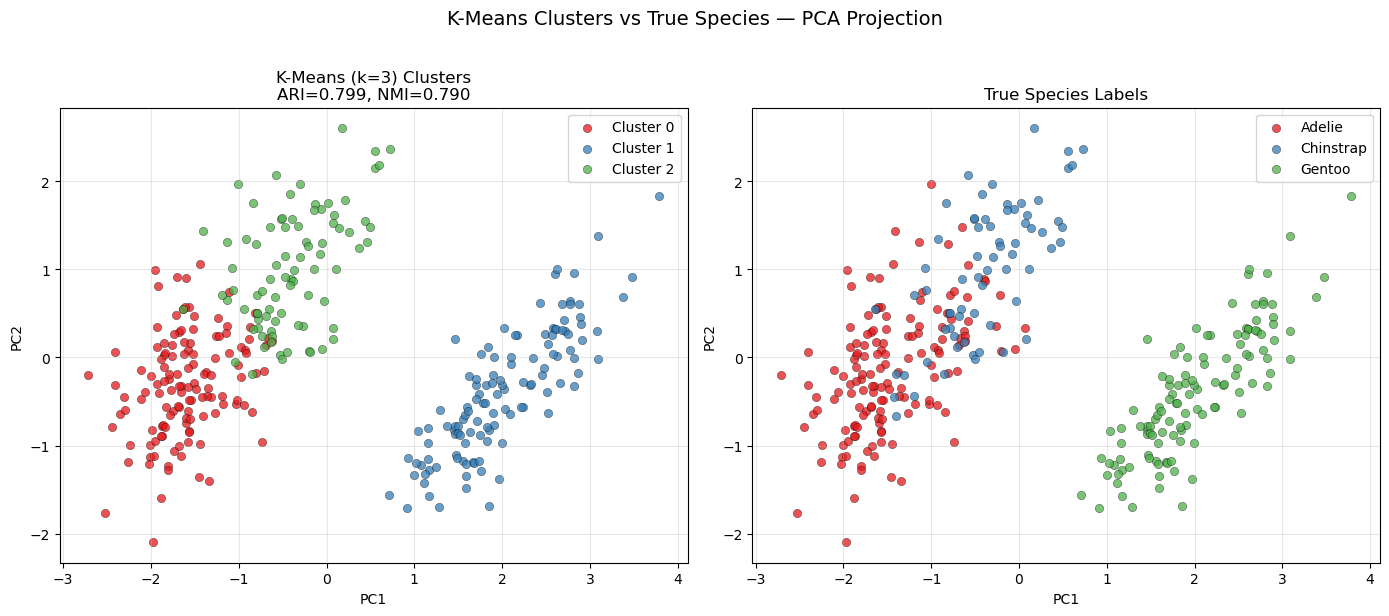

In [18]:
# 4. 1x2 subplot: K-Means clusters | True species — on PCA projection
cluster_colors = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means clusters
for cl in range(3):
    mask = km_penguin_labels == cl
    axes[0].scatter(X_pca_p[mask, 0], X_pca_p[mask, 1],
                    label=f'Cluster {cl}', color=cluster_colors[cl],
                    alpha=0.75, edgecolors='k', linewidths=0.3)
axes[0].set_title(f'K-Means (k=3) Clusters\nARI={ari:.3f}, NMI={nmi:.3f}', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True species
for sp in species_order:
    mask = species_labels == sp
    axes[1].scatter(X_pca_p[mask, 0], X_pca_p[mask, 1],
                    label=sp, color=species_colors[sp],
                    alpha=0.75, edgecolors='k', linewidths=0.3)
axes[1].set_title('True Species Labels', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('K-Means Clusters vs True Species — PCA Projection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Did Unsupervised Learning Rediscover the Species?

**ARI and NMI interpretation:**  
Both scores fall between 0 (random assignment) and 1 (perfect recovery). A high ARI (> 0.7) and high NMI (> 0.7) indicate that the K-Means clusters strongly align with the true species labels — unsupervised learning largely *did* rediscover the three species.

**Where did it succeed?**  
Gentoo penguins are well-separated in feature space (larger body mass, longer flippers), so K-Means reliably isolates them into one cluster. This is clearly visible in the PCA projection: the Gentoo cluster sits far from the other two.

**Where did it struggle?**  
Adelie and Chinstrap share overlapping bill-depth and body-mass ranges, so K-Means occasionally misassigns borderline individuals between those two clusters. The boundary between those two species is less sharp in feature space.

**What does this tell us about unsupervised methods?**  
When the true classes correspond to naturally separated, roughly spherical clusters in feature space, unsupervised clustering can recover them with high fidelity — even without any labels. However, when classes partially overlap or have irregular shapes, unsupervised clustering will struggle at the boundaries. The Penguins result shows that four simple morphological measurements carry enough discriminative signal to make clustering competitive with supervised classification for well-separated species, but labeled data remains valuable for resolving ambiguous cases.